Example 1: $f(x) = x^2 + 3 \sin^2(x)$

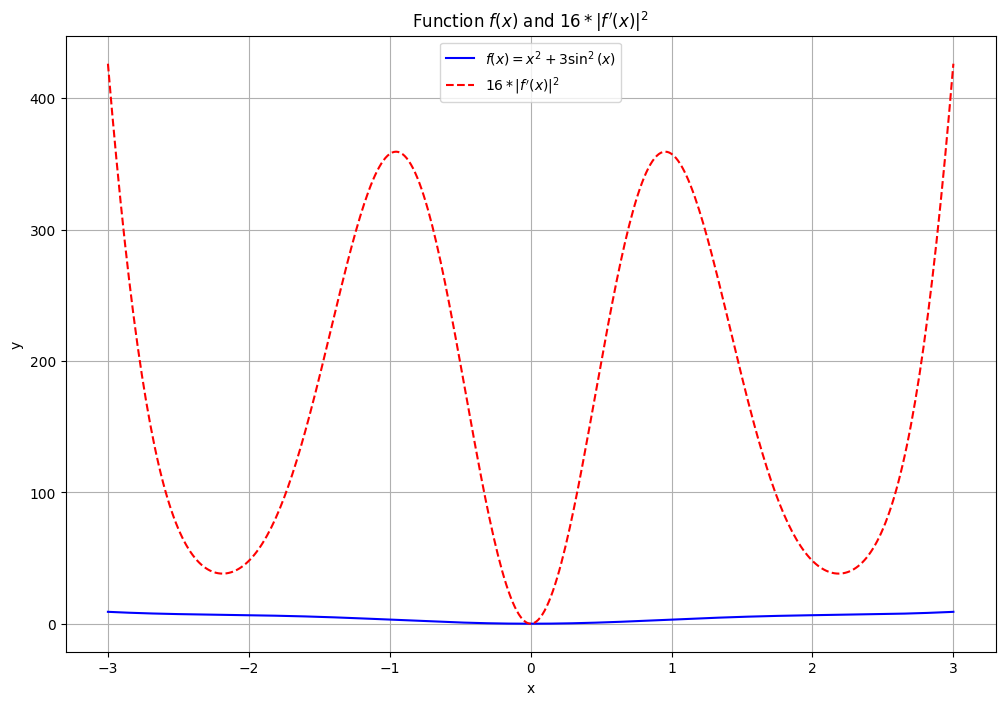

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Define the function and its derivative
f = lambda x: x**2 + 3 * np.sin(x)**2
df = lambda x: 2*x + 6*np.sin(x)*np.cos(x)



# Define the range for x
x = np.linspace(-3, 3, 400)

# Calculate |f'(x)|^2
df_squared = df(x)**2

mu_estimated = 1/32  # This is an assumed value for illustration; the exact value requires a rigorous analysis

# Calculate the PL condition function 1/(2mu) * |f'(x)|^2
pl_function = (1/(2*mu_estimated)) * df_squared

# Plotting
plt.figure(figsize=(12, 8))

# Plot f(x)
plt.plot(x, f(x), label='$f(x) = x^2 + 3\sin^2(x)$', color='blue')

# Plot 1/(2mu) * |f'(x)|^2
plt.plot(x, pl_function, label='$16* |f\'(x)|^2$', linestyle='--', color='red')

plt.xlabel('x')
plt.ylabel('y')
plt.title('Function $f(x)$ and $16* |f\'(x)|^2$')
plt.legend()
plt.grid(True)
plt.show()



Example 2: $f(x) = g(Ax)$ for some strongly convex $g$. Here we set $g(z) =2 z^2 + \cos(z)$.

-3.552713678800501e-15


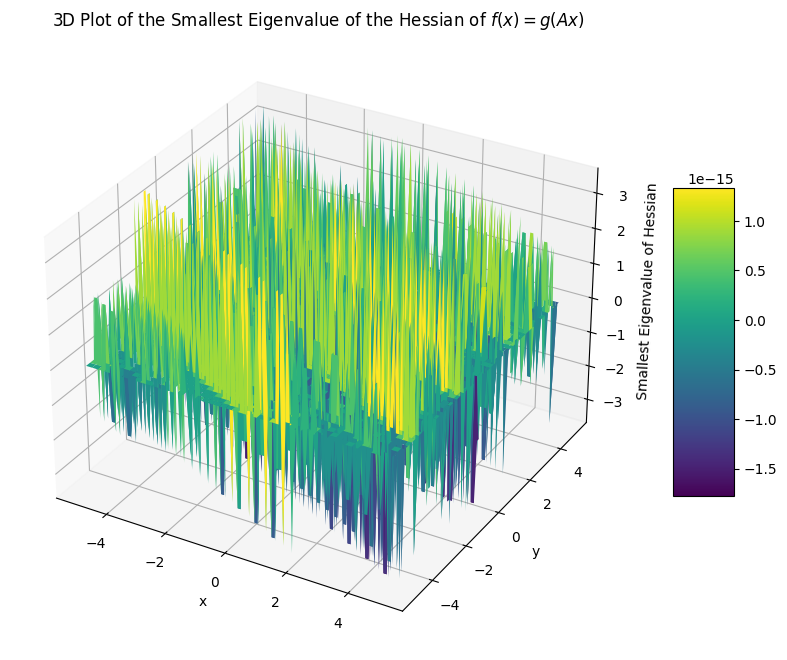

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D


# Define g(z) and its derivatives
def g(z):
    return 2*z**2 + np.cos(z)

def dg(z):
    return 4*z - np.sin(z)

def ddg(z):
    return 4 - np.cos(z)

# Assume a specific A matrix
A = np.array([[1], [2]])  # Example 2x1 matrix

def f(x):
    z = (A.T @ x).item()
    return g(z)

# Function to compute gradient of f
def gradient_f(x):
    z = A.T @ x
    return A * dg(z)

# Function to compute Hessian of f
def hessian_f(x):
    z = A.T @ x
    return A @ A.T * ddg(z)

# Generate a grid within the box [-5, 5] x [-5, 5]
x_range = np.linspace(-5, 5, 100)
y_range = np.linspace(-5, 5, 100)
X, Y = np.meshgrid(x_range, y_range)

# Compute the smallest eigenvalue of the Hessian at each point
smallest_eigenvalues = np.zeros(X.shape)

for i in range(X.shape[0]):
    for j in range(X.shape[1]):
        x_ij = np.array([X[i, j], Y[i, j]])
        H = hessian_f(x_ij)
        eigenvalues = np.linalg.eigvals(H)
        smallest_eigenvalues[i, j] = np.min(eigenvalues)

print(np.min(smallest_eigenvalues))

# Create a 3D plot for the smallest eigenvalue of the Hessian
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot the surface
surf = ax.plot_surface(X, Y, smallest_eigenvalues, cmap='viridis', edgecolor='none')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('Smallest Eigenvalue of Hessian')
ax.set_title('3D Plot of the Smallest Eigenvalue of the Hessian of $f(x) = g(Ax)$')
fig.colorbar(surf, shrink=0.5, aspect=5)

plt.show()



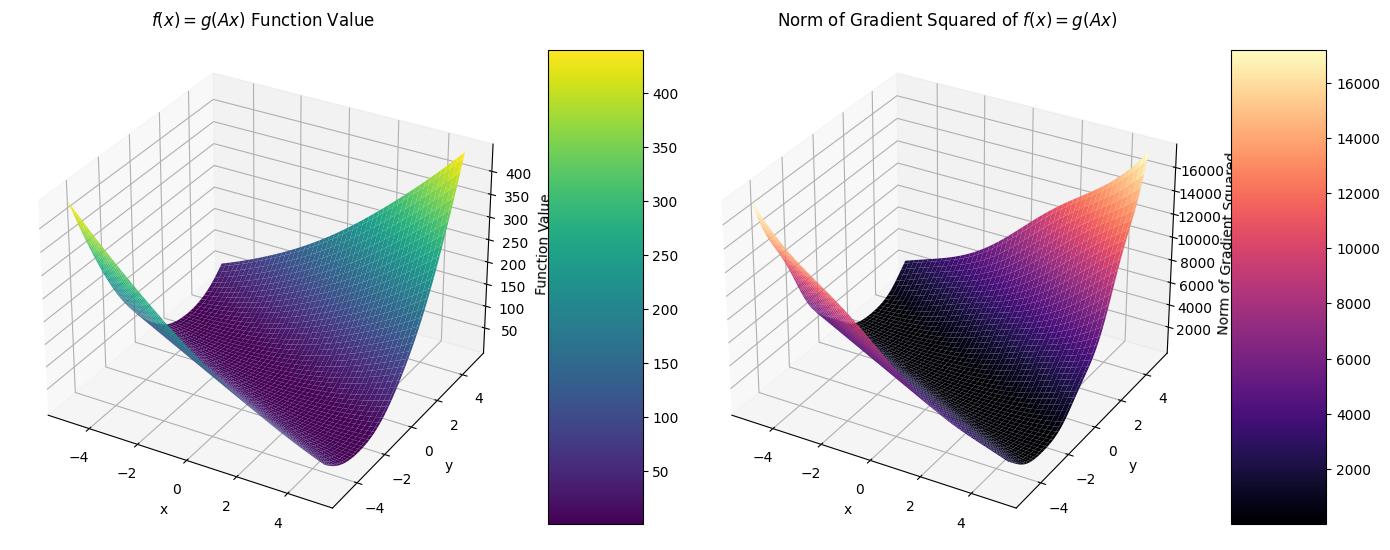

In [10]:


# Function to compute the squared norm of the gradient of f
def norm_gradient_squared(x):
    grad_f = gradient_f(x)
    return np.sum(grad_f**2)

# Compute the function value and squared norm of gradient at each point
function_values = np.zeros(X.shape)
gradient_norms_squared = np.zeros(X.shape)

for i in range(X.shape[0]):
    for j in range(X.shape[1]):
        x_ij = np.array([X[i, j], Y[i, j]])
        function_values[i, j] = f(x_ij)
        gradient_norms_squared[i, j] = norm_gradient_squared(x_ij)

# Create a new 3D plot for function value and squared norm of gradient
fig = plt.figure(figsize=(14, 10))

# Plot for the function value
ax1 = fig.add_subplot(121, projection='3d')
surf1 = ax1.plot_surface(X, Y, function_values, cmap='viridis', edgecolor='none')
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_zlabel('Function Value')
ax1.set_title('$f(x) = g(Ax)$ Function Value')
fig.colorbar(surf1, shrink=0.5, aspect=5, ax=ax1)

# Plot for the squared norm of the gradient
ax2 = fig.add_subplot(122, projection='3d')
surf2 = ax2.plot_surface(X, Y, gradient_norms_squared, cmap='magma', edgecolor='none')
ax2.set_xlabel('x')
ax2.set_ylabel('y')
ax2.set_zlabel('Norm of Gradient Squared')
ax2.set_title('Norm of Gradient Squared of $f(x) = g(Ax)$')
fig.colorbar(surf2, shrink=0.5, aspect=5, ax=ax2)

plt.tight_layout()
plt.show()


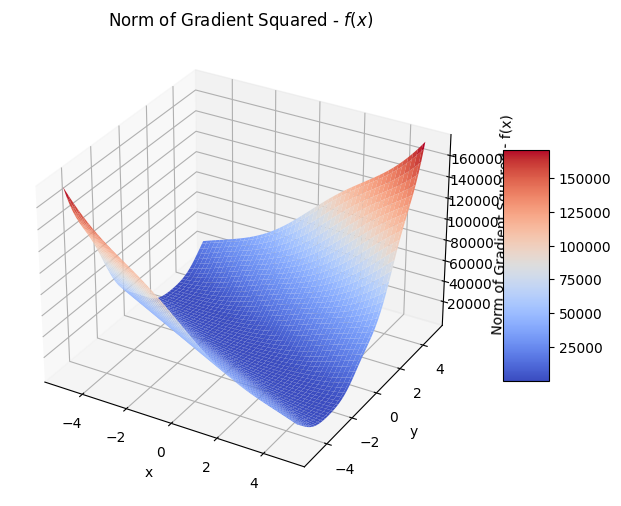

the smallest value of $10* \|gradient\|^2 - f(x) is 0.1443409460846936


In [17]:
# Compute the difference: Norm of Gradient Squared - f(x)
gradient_norm_minus_f = 10*gradient_norms_squared - function_values

# Create a 3D plot for the difference
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

# Plot the surface
surf = ax.plot_surface(X, Y, gradient_norm_minus_f, cmap='coolwarm', edgecolor='none')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('Norm of Gradient Squared - f(x)')
ax.set_title('Norm of Gradient Squared - $f(x)$')
fig.colorbar(surf, shrink=0.5, aspect=5)

plt.show()


print(f"the smallest value of $10* \|gradient\|^2 - f(x) is {np.min(gradient_norm_minus_f)}")